In [ ]:
import csv


In [ ]:
! pip install spacy

In [ ]:
import spacy
import os
import csv


In [ ]:
class Corpus(object):
    def __init__(self,filename):
      self.filename = filename
      self.nlp = spacy.blank("en")
    def __iter__(self):
      with open(self.filename, "r") as i:
        reader = csv.reader(i, delimiter=",")
        for _, abstarct in reader:
          tokens = [t.text.lower() for t in self.nlp(abstarct)]
          yield tokens
documents = Corpus('/content/arxiv.csv')

In [ ]:
documents

In [ ]:
documents=list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [ ]:
! pip install spacy gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.7 MB/s eta 0:00:00


In [ ]:
import gensim
model = gensim.models.Word2Vec(documents,min_count=100,window=5,vector_size=100)

In [ ]:
model.wv["nlp"]

array([ 0.6472638 , -0.33695635,  1.1511449 ,  0.6867785 ,  1.7220409 ,
        0.51125795, -0.8545943 , -1.1681294 , -0.44418454,  1.5106585 ,
       -1.0324937 ,  0.27366242, -0.7731473 , -1.1368785 , -1.497697  ,
        0.12239157, -0.80258995,  0.24261194, -2.112508  ,  1.5684655 ,
        0.2240372 , -1.1246386 ,  0.4817666 , -1.0246389 , -1.8966457 ,
        0.33084196,  0.21340989,  1.7118716 ,  1.62208   ,  1.1845174 ,
       -2.2365825 ,  1.1824507 ,  0.5870217 , -0.42104593, -1.0035558 ,
       -0.27071217, -2.0047762 ,  0.5732472 , -0.6555726 , -1.2495196 ,
        1.71317   , -1.0451128 ,  1.209736  , -0.32650822,  0.3309498 ,
        2.3591537 ,  2.0149574 , -3.0199547 ,  0.13156033, -2.035091  ,
       -1.9160907 ,  1.2179354 , -0.30948138,  1.6722027 , -0.3148726 ,
        0.29516965,  0.1739131 ,  0.68819475, -0.41541153, -1.1374794 ,
       -1.7334253 , -0.39143914, -0.32176867,  0.6550944 , -0.45580438,
        1.0737773 ,  2.0292726 ,  1.1779901 , -0.346279  , -0.19

In [ ]:
print(model.wv.similarity("nmt","smt"))
print(model.wv.similarity("nmt","ner"))

0.62152857
0.36353412


In [ ]:
model.wv.similar_by_word("bert",topn=10)

[('transformer', 0.7489749193191528),
 ('transformers', 0.7435111999511719),
 ('roberta', 0.7320598363876343),
 ('pretrained', 0.7111496329307556),
 ('elmo', 0.7089114189147949),
 ('lm', 0.5995560884475708),
 ('lstm', 0.5910497903823853),
 ('r', 0.5869709849357605),
 ('multilingual', 0.5784027576446533),
 ('bilstm', 0.5754157900810242)]

In [ ]:
model.wv.most_similar(positive=["transformer","lstm"],negative=["bert"],topn=10)

[('recurrent', 0.8274309635162354),
 ('rnn', 0.8122296333312988),
 ('gated', 0.7517373561859131),
 ('forward', 0.7376594543457031),
 ('convolutional', 0.7248841524124146),
 ('convolution', 0.7162061929702759),
 ('attentive', 0.708984911441803),
 ('memory', 0.7082481384277344),
 ('feed', 0.6922144889831543),
 ('encoder', 0.6902271509170532)]

In [ ]:
model.wv.most_similar(positive=["trees"],topn=5)

[('dependency', 0.7688818573951721),
 ('parse', 0.7665040493011475),
 ('tree', 0.7641226053237915),
 ('structures', 0.6904202699661255),
 ('parsers', 0.6857743859291077)]

In [ ]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split()))

svm


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word="bert"
selected_words=[w[0] for w in model.wv.most_similar(positive=[target_word],topn=200)]+[target_word]
embeddings=[model.wv[w] for w in selected_words]+model.wv["bert"]

mapped_embeddings=TSNE(n_components=2,metric="cosine",init="pca").fit_transform(embeddings)


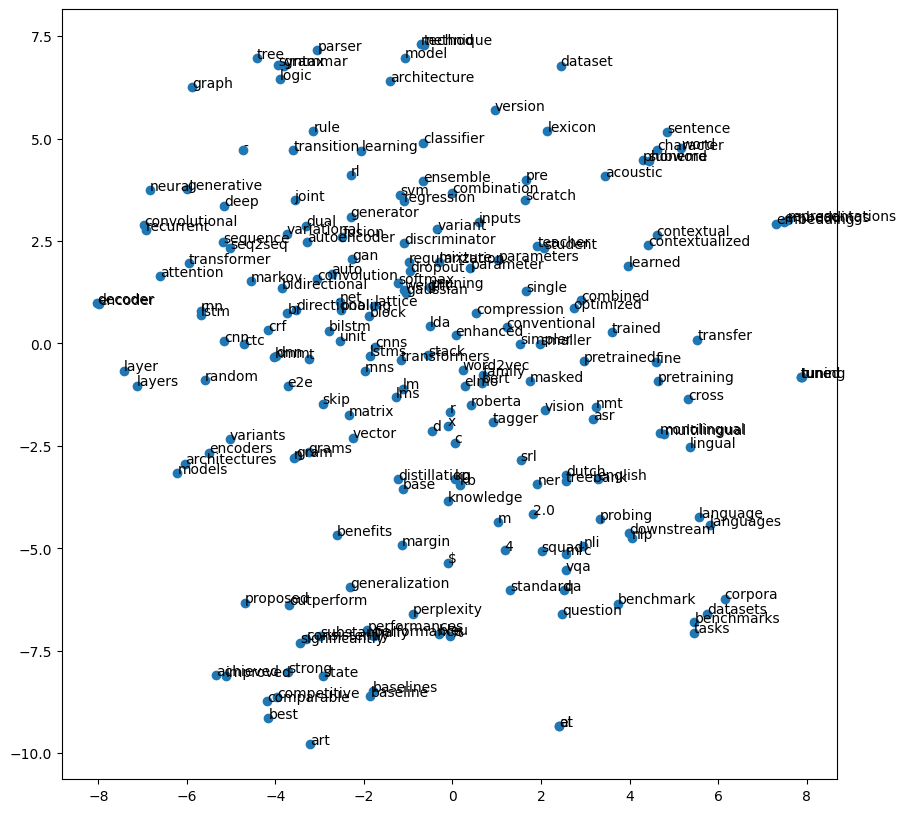

In [ ]:
plt.figure(figsize=(10,10))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)
for i, txt in enumerate(selected_words):
  plt.annotate(txt,(x[i],y[i]))